# Image Classification with YOLO

## **Imports**

In [2]:
%%capture
!pip install ultralytics

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## **Load Dataset**

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog", force_download=True)

print("Path to dataset files:", path)
# Path to dataset files: /kaggle/input/cat-and-dog

Path to dataset files: /kaggle/input/cat-and-dog


In [5]:
input_root_dir = "/kaggle/input/cat-and-dog"
train_dir = os.path.join(input_root_dir, "training_set", "training_set")
test_dir = os.path.join(input_root_dir, "test_set", "test_set")
categories = ["cats", "dogs"]

In [6]:
!mkdir cat_dog
!cp -r {train_dir} /content/cat_dog/
!cp -r {test_dir} /content/cat_dog/

In [7]:
%cd /content/cat_dog/
!mv test_set val
!mv training_set train
%cd /content/

/content/cat_dog
/content


## **Train Model**

In [ ]:
# !rm -r runs

In [ ]:
# Load a model
model = YOLO("yolo11n-cls.pt")  # load a pretrained model (recommended for training)

In [ ]:
%%time
# Train the model
results = model.train(data="/content/cat_dog", epochs=10, imgsz=64, device = "cuda")

In [ ]:
# Export the model to ONNX
# model.export(format="onnx")

In [ ]:
%%capture
!zip -r results.zip runs

## **Visualize**
[Results Link](https://github.com/RezaTaheri01/my-ml-journey/tree/main/Results/ml_0015_Yolov8/runs_epochs_50_imgsz_64/runs/classify/train)

In [ ]:
results_path = '/content/runs/classify/train/results.csv'

results = pd.read_csv(results_path)

In [ ]:
results.head()

,epoch,time,train/loss,metrics/accuracy_top1,metrics/accuracy_top5,val/loss,lr/pg0,lr/pg1,lr/pg2
0,1,42.1258,0.52792,0.85714,1,0.37975,0.000555,0.000555,0.000555
1,2,83.0348,0.49454,0.86703,1,0.35666,0.001088,0.001088,0.001088
2,3,124.3600,0.48029,0.85912,1,0.35078,0.001600,0.001600,0.001600
3,4,163.8830,0.44247,0.87296,1,0.30480,0.001568,0.001568,0.001568
4,5,203.2970,0.42072,0.84775,1,0.34865,0.001535,0.001535,0.001535


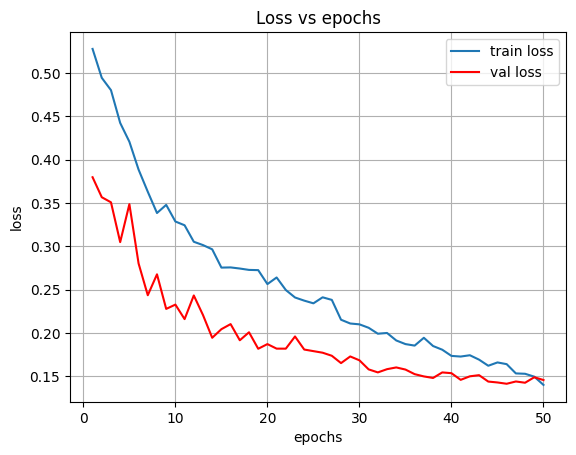

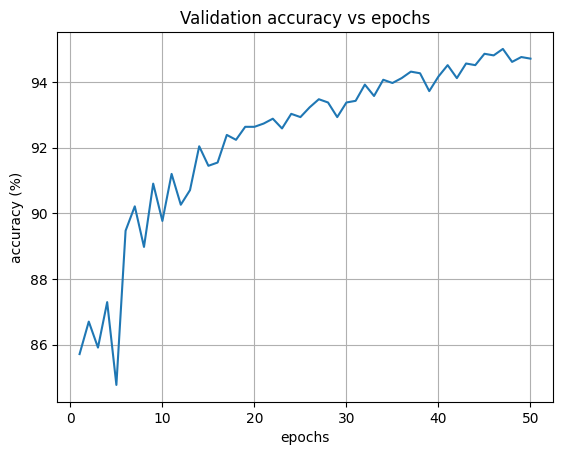

In [ ]:
plt.figure()
plt.plot(results['epoch'], results['train/loss'], label='train loss')
plt.plot(results['epoch'], results['val/loss'], label='val loss', c='red')
plt.grid()
plt.title('Loss vs epochs')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.legend()


plt.figure()
plt.plot(results['epoch'], results['metrics/accuracy_top1'] * 100)
plt.grid()
plt.title('Validation accuracy vs epochs')
plt.ylabel('accuracy (%)')
plt.xlabel('epochs')

plt.show()

## **Prediction**

In [8]:
from google.colab import files

[Model Link](https://github.com/RezaTaheri01/my-ml-journey/tree/main/Results/ml_0015_Yolov8/runs_epochs_50_imgsz_64/runs/classify/train/weights)

Use this to upload model in /content/"model-name":
* uploaded = files.upload()

In [10]:
model_p = YOLO('./runs/classify/train/weights/last.pt')  # load a custom model

In [17]:
uploaded = files.upload()

Saving Cat_August_2010-4.jpg to Cat_August_2010-4.jpg


In [18]:
image_filename = next(iter(uploaded)) # Get the first (and likely only) filename

In [19]:
results = model_p(image_filename)  # predict on an image

names_dict = results[0].names

probs = results[0].probs.data.tolist()

print(names_dict)
print(probs)

print(names_dict[np.argmax(probs)])


image 1/1 /content/Cat_August_2010-4.jpg: 64x64 cats 1.00, dogs 0.00, 5.0ms
Speed: 5.7ms preprocess, 5.0ms inference, 0.1ms postprocess per image at shape (1, 3, 64, 64)
{0: 'cats', 1: 'dogs'}
[0.998475968837738, 0.0015239936765283346]
cats
